<a href="https://colab.research.google.com/github/flaviocrispin/tecnica_programacao/blob/colaborador%2Fwillianadb/Aula_pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Projetos/DimCustomer.csv")

In [3]:
df.head()

,Unnamed: 0,CustomerKey,GeographyKey,FirstName,LastName,BirthDate,MaritalStatus,Gender,YearlyIncome,TotalChildren,NumberChildrenAtHome,Education,Occupation,HouseOwnerFlag,NumberCarsOwned
0,0,1,680,Jon,Yang,1966-04-08,M,M,90000.0,2.0,0.0,Bachelors,Professional,1.0,0.0
1,1,2,692,Eugene,Huang,1965-05-14,S,M,60000.0,3.0,3.0,Bachelors,Professional,0.0,1.0
2,2,3,493,Ruben,Torres,1965-08-12,M,M,60000.0,3.0,3.0,Bachelors,Professional,1.0,1.0
3,3,4,519,Christy,Zhu,1968-02-15,S,F,70000.0,0.0,0.0,Bachelors,Professional,0.0,1.0
4,4,5,706,Elizabeth,Johnson,1968-08-08,S,F,80000.0,5.0,5.0,Bachelors,Professional,1.0,4.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18869 entries, 0 to 18868
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            18869 non-null  int64  
 1   CustomerKey           18869 non-null  int64  
 2   GeographyKey          18869 non-null  int64  
 3   FirstName             18869 non-null  object 
 4   LastName              18869 non-null  object 
 5   BirthDate             18869 non-null  object 
 6   MaritalStatus         18869 non-null  object 
 7   Gender                18869 non-null  object 
 8   YearlyIncome          18869 non-null  float64
 9   TotalChildren         18869 non-null  float64
 10  NumberChildrenAtHome  18869 non-null  float64
 11  Education             18869 non-null  object 
 12  Occupation            18869 non-null  object 
 13  HouseOwnerFlag        18869 non-null  float64
 14  NumberCarsOwned       18869 non-null  float64
dtypes: float64(5), int6

In [16]:
df.shape

(18869, 15)

In [18]:
#@title Quantidade de linhas e colunas
print(f"Quantidade de linhas {df.shape[0]}")
print(f"Quantidade de colunas {df.shape[1]}")

Quantidade de linhas 18869
Quantidade de colunas 15


Quantidade de colunas 15


In [20]:
df_novo = df[['FirstName','BirthDate','MaritalStatus','YearlyIncome']]

In [22]:
df_novo.head()

,FirstName,BirthDate,MaritalStatus,YearlyIncome
0,Jon,1966-04-08,M,90000.0
1,Eugene,1965-05-14,S,60000.0
2,Ruben,1965-08-12,M,60000.0
3,Christy,1968-02-15,S,70000.0
4,Elizabeth,1968-08-08,S,80000.0


In [23]:
novodf = df.copy()


In [24]:
df['data_nascimento'] = pd.to_datetime(df['BirthDate'])

In [26]:
df.drop('Unnamed: 0', inplace=True, axis=1)

In [27]:
df.describe()

,CustomerKey,GeographyKey,YearlyIncome,TotalChildren,NumberChildrenAtHome,HouseOwnerFlag,NumberCarsOwned,data_nascimento
count,18869.000000,18869.000000,1.886900e+04,18869.000000,18869.000000,18869.000000,18869.000000,18869
mean,9440.631459,574.910435,2.601749e+05,1.856219,1.034077,0.673274,1.513753,1962-05-05 06:14:05.958980352
min,1.000000,423.000000,1.000000e+04,0.000000,0.000000,0.000000,0.000000,1910-08-13 00:00:00
25%,4718.000000,506.000000,3.000000e+04,0.000000,0.000000,0.000000,1.000000,1954-11-14 00:00:00
50%,9435.000000,568.000000,6.000000e+04,2.000000,0.000000,1.000000,2.000000,1963-11-02 00:00:00
75%,14152.000000,645.000000,8.000000e+04,3.000000,2.000000,1.000000,2.000000,1970-12-27 00:00:00
max,19145.000000,952.000000,1.000000e+07,5.000000,5.000000,1.000000,4.000000,1990-12-27 00:00:00
std,5456.841811,84.163867,1.406071e+06,1.615868,1.541922,0.469029,1.146417,NaN


In [30]:
df['Occupation'].value_counts()

,count
Occupation,
Professional,5606
Skilled Manual,4649
Management,3147
Clerical,3014
Manual,2453


In [31]:
df['Education'].value_counts()

,count
Education,
Bachelors,5448
Partial College,5138
High School,3362
Graduate Degree,3260
Partial High School,1661


In [32]:
df['Gender'].value_counts()

,count
Gender,
M,9525
F,9344


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

<function matplotlib.pyplot.show(close=None, block=None)>

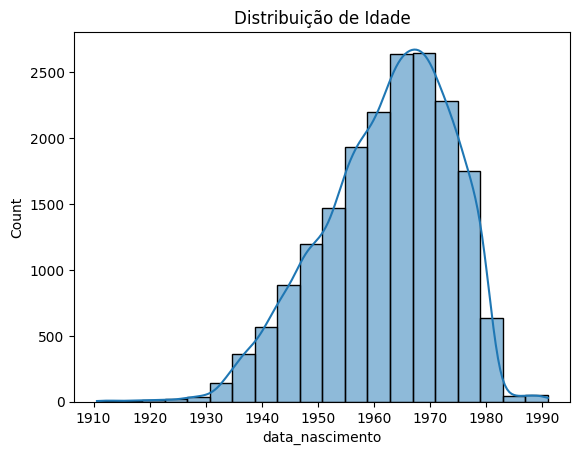

In [42]:
#@title Histograma distribuição de idade
plt.title('Distribuição de Idade')
sns.histplot(df['data_nascimento'], bins=20, kde=True)
plt.show

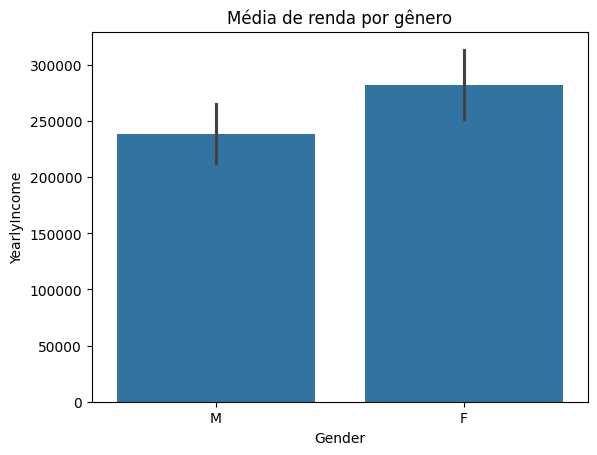

In [47]:
sns.barplot(x='Gender', y='YearlyIncome', data=df)
plt.title('Média de renda por gênero')
plt.show()

In [49]:
df['Gender'].replace('M', 'Masculino', inplace=True)
df['Gender'].replace('F', 'Feminino', inplace=True)

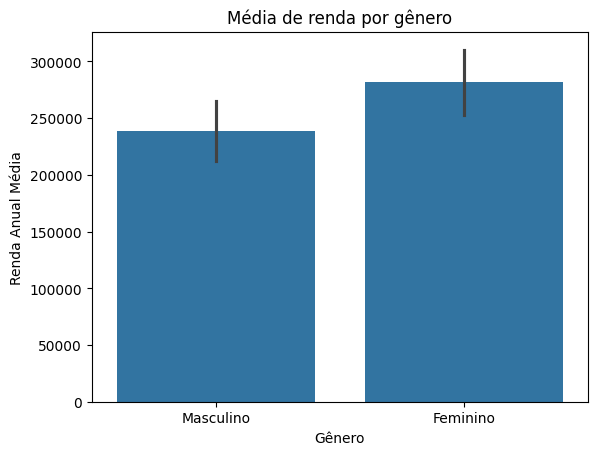

In [53]:
sns.barplot(x='Gender', y='YearlyIncome', data=df)
plt.title('Média de renda por gênero')
plt.xlabel('Gênero')
plt.ylabel('Renda Anual Média')
plt.savefig('/content/drive/MyDrive/Projetos/fig_media_renda')
plt.show()

In [54]:
def gerar_grafico(nome_coluna):
    sns.histplot(df[nome_coluna], bins=20, kde=True)
    plt.title(f'Histograma')
    plt.xlabel(nome_coluna)
    plt.ylabel('Frequência')
    plt.savefig(f'/content/drive/MyDrive/Projetos/fig_{nome_coluna}')
    plt.show

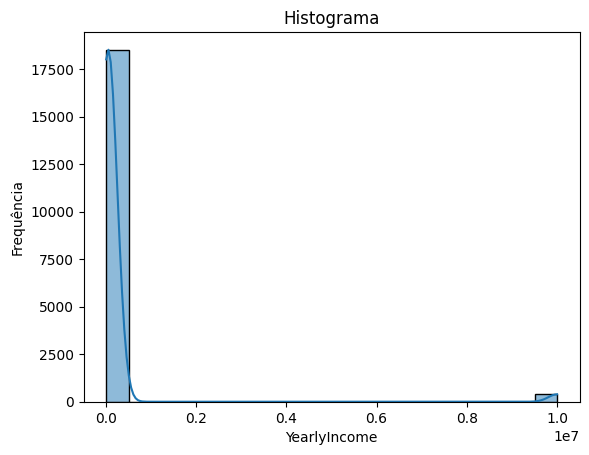

In [55]:
gerar_grafico('YearlyIncome')

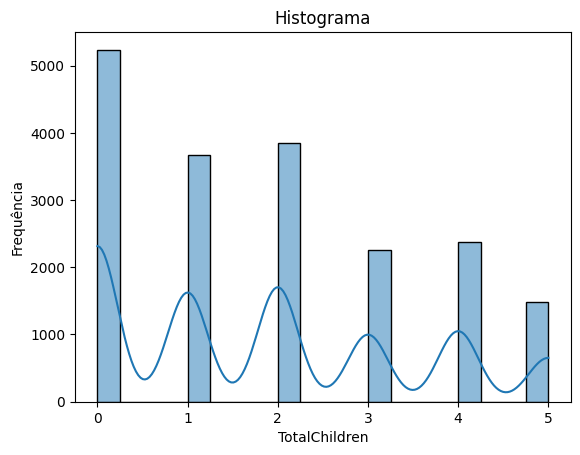

In [57]:
gerar_grafico('TotalChildren')